In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from core import *

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/var/folders/bs/pjtn_x6x0vlg303wglbxqthm0000gn/T/ipykernel_97223/777383303.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load("/Users/daniel

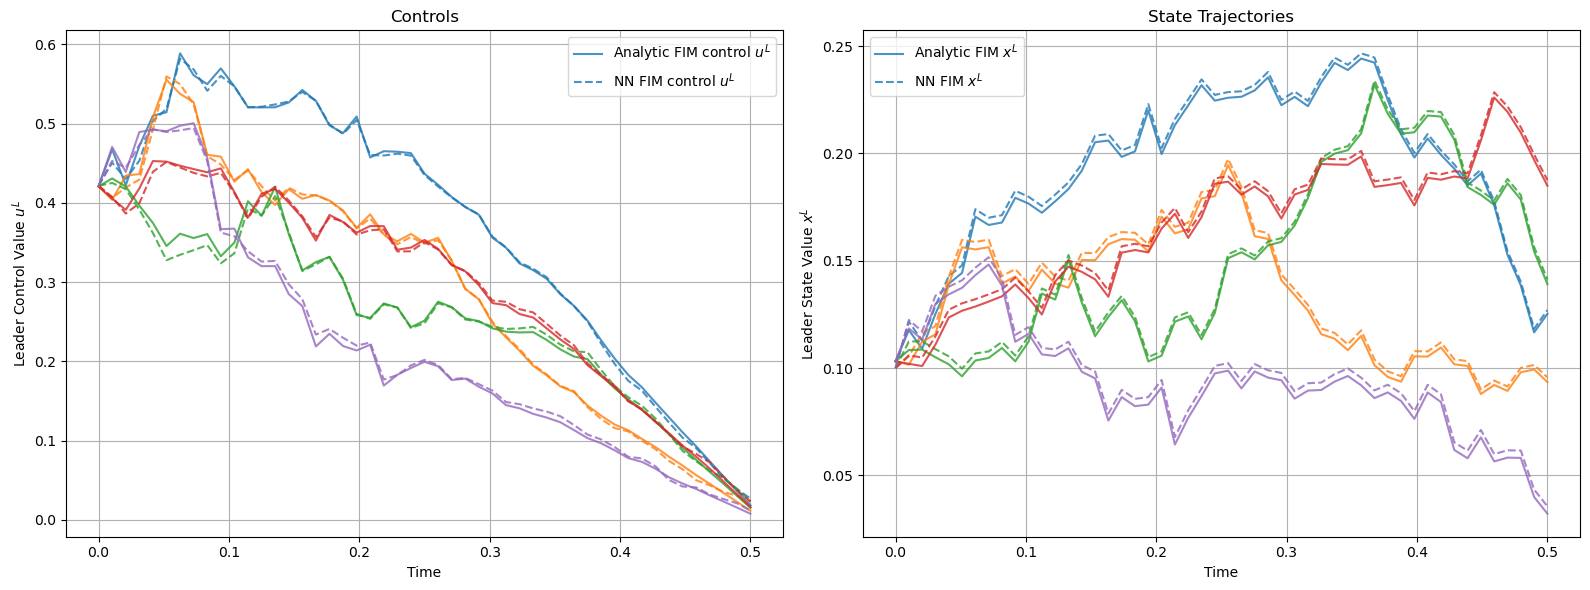

In [10]:
# plot learned vs analytic leader control and state trajectories

def F(x):
    return 0.2 * torch.sin(2*np.pi * x / params.T)
    # return 0*torch.ones_like(x, device=params.device)

N = 50
T = 0.5

params = SystemParams()
params.A_L, params.A_F = -1.0, -1.0
params.B_L, params.B_F = 1.0, 1.0
params.sig_L, params.sig_F = 0.1, 0.1
params.M_true = 1.0
params.lamb_F = 1.0
params.lamb_L = .6
params.Q_L_T = 0.0
params.Q_L, params.Q_F = 0., 1.0
params.R_L, params.R_F = 1.0, 1.0
params.X_L_0, params.X_F_0 = 0.1, 0.1
params.T, params.N = 0.5, 50
params.device = device
params.time_grid = torch.linspace(0, params.T, params.N+1, device=params.device)
params.dt = params.T / params.N

leader_analytic = LeaderLBSolver(params, F)

net = DeepLSTMController()
net.load_state_dict(torch.load("/Users/danielralston/Desktop/Strategic-Inference-Stackleburg-Games/src/runs/cutest_negatively/loss_-2.392e-02_upd_1495.pt", map_location=device))
net.to(device)
u_NN = make_nn_policy(net, params)

seed_plot = 123
batch_size_plot = 5000   # tune as desired
torch.manual_seed(seed_plot)
X_L_a_batch, U_L_a_batch = leader_analytic.simulate(batch=batch_size_plot, seed=seed_plot)
X_L_nn_batch, U_L_nn_batch = simulate_leader(u_NN, params, batch=batch_size_plot, seed=seed_plot)
X_L_nn_batch, U_L_nn_batch = X_L_nn_batch.detach(), U_L_nn_batch.detach()

samples = [1,2,3,4,5]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left subplot: leader control trajectories
for i, ind in enumerate(samples):
    color = f'C{i}'
    ax1.plot(torch.linspace(0, params.T, U_L_a_batch[ind].shape[0]),
             U_L_a_batch[ind].cpu().numpy(),
             linestyle='-', color=color,
             alpha=0.8,
             label=f'Analytic FIM control $u^L$' if i == 0 else None)
    ax1.plot(torch.linspace(0, params.T, U_L_a_batch[ind].shape[0]),
             U_L_nn_batch[ind].cpu().numpy(),
             linestyle='--', color=color,
             alpha=0.8,
             label=f'NN FIM control $u^L$' if i == 0 else None)
ax1.set_title(f'Controls')
ax1.set_xlabel('Time')
ax1.set_ylabel('Leader Control Value $u^L$')
ax1.legend()
ax1.grid(True)

# Right subplot: leader state trajectories
for i, ind in enumerate(samples):
    color = f'C{i}'
    ax2.plot(torch.linspace(0, params.T, X_L_a_batch[ind].shape[0]),
             X_L_a_batch[ind].cpu().numpy(),
             linestyle='-', color=color,
             alpha=0.8,
             label=f'Analytic FIM $x^L$' if i == 0 else None)
    ax2.plot(torch.linspace(0, params.T, X_L_nn_batch[ind].shape[0]),
             X_L_nn_batch[ind].cpu().numpy(),
             linestyle='--', color=color,
             alpha=0.8,
             label=f'NN FIM $x^L$' if i == 0 else None)
ax2.set_title(f'State Trajectories')
ax2.set_xlabel('Time')
ax2.set_ylabel('Leader State Value $x^L$')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# plt.figure(figsize=(8, 6))
# for i, ind in enumerate(samples):
#     c = f'C{i}'
#     plt.plot(torch.linspace(0, params.T, U_L_a_batch[ind].shape[0]),
#              U_L_a_batch[ind].cpu().numpy(),
#              linestyle='-', color=c,
#              alpha=0.8,
#              label=f'Analytic FIM control $u^L$' if i == 0 else None)
#     plt.plot(torch.linspace(0, params.T, U_L_a_batch[ind].shape[0]),   
#              U_L_nn_batch[ind].cpu().numpy(),
#              linestyle='--', color=c,
#              alpha=0.8,
#              label=f'NN FIM control $u^L$' if i == 0 else None)
# plt.xlabel('Time')
# plt.ylabel('Leader Control Value Fisher Information Maximization $u^L$')
# # plt.suptitle(f'Sample Control Trajectory with $\lambda_L={lam_L}$')
# # plt.title(f'Analytic cost of lower bound: {mc_lb:.3}, NN cost of lower bound: {nn_lb:.3}')
# # plt.title(f'Sample Control Trajectory with $\lambda_L={lam_L}$, NN trained with exact cost')
# plt.legend()
# plt.tight_layout()
# plt.show()


# plt.figure(figsize=(8, 6))
# for i, ind in enumerate(samples):
#     c = f'C{i}'
#     plt.plot(torch.linspace(0, params.T, X_L_a_batch[ind].shape[0]),
#              X_L_a_batch[ind].cpu().numpy(),
#              linestyle='-', color=c,
#              alpha=0.8,
#              label=f'Analytic FIM $x^L$' if i == 0 else None)
#     plt.plot(torch.linspace(0, params.T, X_L_nn_batch[ind].shape[0]),
#              X_L_nn_batch[ind].cpu().numpy(),
#              linestyle='--', color=c,
#              alpha=0.8,
#              label=f'NN FIM $x^L$' if i == 0 else None)

# plt.xlabel('Time')
# plt.ylabel('Leader State Value $x^L$')
# # plt.suptitle(f'Sample State Trajectories with $\lambda_L={lam_L}$')
# # plt.title(f'Analytic cost of lower bound: {mc_lb:.3}, NN cost of lower bound: {nn_lb:.3}')
# plt.legend()
# plt.tight_layout()
# plt.show()



/var/folders/bs/pjtn_x6x0vlg303wglbxqthm0000gn/T/ipykernel_69726/3985797289.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(os.getcwd() 

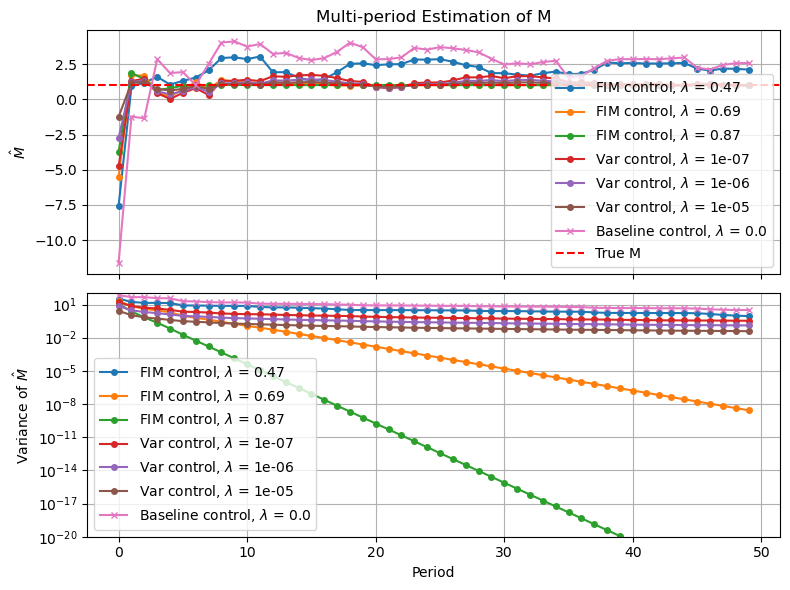

In [82]:
# multi-period estimation of system

def F(x):
    return 0.2 * torch.sin(2*np.pi * x / params.T)
    # return 0*torch.ones_like(x, device=params.device)

N = 50
T = 0.5

params = SystemParams()
params.A_L, params.A_F = -1.0, -1.0
params.B_L, params.B_F = 1.0, 1.0
params.sig_L, params.sig_F = 0.1, 0.1
params.M_true = 1.0
params.lamb_F = 1.
# params.lamb_L = 1.0
params.Q_L_T = 1.0
params.Q_L, params.Q_F = 0.0, 1.0
params.R_L, params.R_F = 1.0, 1.0
params.X_L_0, params.X_F_0 = 0.1, 0.1
params.T, params.N = T, N
params.device = device
params.time_grid = torch.linspace(0, params.T, params.N + 1, device=params.device)
params.dt = params.T / params.N

num_periods = 50
analy_lamb_L_vals = [ .47, .69, .87]
estM = {}
varM = {}
for val in analy_lamb_L_vals:
    params.lamb_L = val
    leader_analytic = LeaderLBSolver(params, F)
    curr_X_L_0, curr_X_F_0 = 0.1, 0.1
    running_prec = [0.0]
    running_estM = [0.0]
    running_var = [0.0]
    for i in range(num_periods):
        params.X_L_0, params.X_F_0 = curr_X_L_0, curr_X_F_0
        X_L, U_L = leader_analytic.simulate(batch=1, seed=2*i)
        # X_L, U_L = simulate_leader(leader_controller, params, batch=1, seed=2*i)
        X_F, U_F = simulate_follower(X_L, params, batch=1, seed=2*i+1)
        a_grid = compute_a_grid(params)
        f_grid = compute_f_grid(params)
        g = compute_b_grid(params, a_grid, X_L) / params.M_true
        num_first = int_trapz(f_grid[1:] * g * X_F, params.dt)
        num_second = sum([g[0, j] * (X_F[0, j+1] - X_F[0, j]) for j in range(X_F.shape[1] - 1)])
        denom = int_trapz((params.B_F**2/params.R_F) * (g**2), params.dt)
        curr_M = (num_first - num_second) / denom
        running_prec.append(running_prec[-1] + int_trapz(g**2, params.dt))
        new_M_est = (running_prec[-2]/ running_prec[-1]) * running_estM[-1] + (int_trapz(g**2, params.dt) / running_prec[-1]) * curr_M
        new_var_est = ((params.sig_F**2 * params.R_F**2)/(params.B_F**4)) * (1/running_prec[-1])
        if torch.isnan(new_M_est):
            new_M_est = running_estM[-1]
        if torch.isnan(new_var_est):
            new_var_est = running_var[-1]
        running_estM.append(new_M_est)
        running_var.append(new_var_est)
        curr_X_L_0 = X_L[0, -1].item()
        curr_X_F_0 = X_F[0, -1].item()
    estM[f"FIM control, $\lambda$ = {val}"] = running_estM[1:]  # skip the initial 0
    varM[f"FIM control, $\lambda$ = {val}"] = running_var[1:]  # skip the initial 0
    # plt.plot(running_estM[1:])
    # plt.plot(running_var[1:])

curr_X_L_0, curr_X_F_0 = 0.1, 0.1
params.lamb_L = 0
baseline_analytic = LeaderLBSolver(params, F)
running_estM = [0.0]
running_prec = [0.0]
running_var = [0.0]
baseline_estM = None
baseline_varM = None

for i in range(num_periods):
    params.X_L_0, params.X_F_0 = curr_X_L_0, curr_X_F_0
    X_L, U_L = baseline_analytic.simulate(batch=1, seed=2*i)
    X_F, U_F = simulate_follower(X_L, params, batch=1, seed=2*i+1)
    a_grid = compute_a_grid(params)
    f_grid = compute_f_grid(params)
    g = compute_b_grid(params, a_grid, X_L) / params.M_true
    num_first = int_trapz(f_grid[1:] * g * X_F, params.dt)
    num_second = sum([g[0, j] * (X_F[0, j+1] - X_F[0, j]) for j in range(X_F.shape[1] - 1)])
    denom = int_trapz((params.B_F**2/params.R_F) * (g**2), params.dt)
    curr_M = (num_first - num_second) / denom
    running_prec.append(running_prec[-1] + int_trapz(g**2, params.dt))
    new_M_est = (running_prec[-2]/ running_prec[-1]) * running_estM[-1] + (int_trapz(g**2, params.dt) / running_prec[-1]) * curr_M
    new_var_est = ((params.sig_F**2 * params.R_F**2)/(params.B_F**4)) * (1/running_prec[-1])
    if torch.isnan(new_M_est):
        new_M_est = running_estM[-1]
    if torch.isnan(new_var_est):
        new_var_est = running_var[-1]
    running_estM.append(new_M_est)
    running_var.append(new_var_est)
    curr_X_L_0 = X_L[0, -1].item()
    curr_X_F_0 = X_F[0, -1].item()
baseline_estM = running_estM[1:]  # skip the initial 0
baseline_varM = running_var[1:]  # skip the initial 0

net_weight_files = [
    (1e-7, "/runs/promoting_madame/loss_3.532e-02_upd_6264.pt"),
    (1e-6, "/runs/how'd_fury/loss_1.416e-01_upd_7945.pt"),
    (1e-5, "/runs/arbitrary_aisle/loss_5.186e-01_upd_9910.pt"),
]

for lam_exact_val, weight_file in net_weight_files:
    net = DeepLSTMController()
    net.load_state_dict(torch.load(os.getcwd() + weight_file, map_location=device))
    net.to(device)
    u_NN = make_nn_policy(net, params)
    curr_X_L_0, curr_X_F_0 = 0.1, 0.1
    running_prec = [0.0]
    running_estM = [0.0]
    running_var = [0.0]
    for i in range(num_periods):
        params.X_L_0, params.X_F_0 = curr_X_L_0, curr_X_F_0
        X_L, U_L = simulate_leader(u_NN, params, batch=1, seed=2*i)
        X_L, U_L = X_L.detach(), U_L.detach()
        X_F, U_F = simulate_follower(X_L, params, batch=1, seed=2*i+1)
        a_grid = compute_a_grid(params)
        f_grid = compute_f_grid(params)
        g = compute_b_grid(params, a_grid, X_L) / params.M_true
        num_first = int_trapz(f_grid[1:] * g * X_F, params.dt)
        num_second = sum([g[0, j] * (X_F[0, j+1] - X_F[0, j]) for j in range(X_F.shape[1] - 1)])
        denom = int_trapz((params.B_F**2/params.R_F) * (g**2), params.dt)
        curr_M = (num_first - num_second) / denom
        running_prec.append(running_prec[-1] + int_trapz(g**2, params.dt))
        new_M_est = (running_prec[-2]/ running_prec[-1]) * running_estM[-1] + (int_trapz(g**2, params.dt) / running_prec[-1]) * curr_M
        new_var_est = ((params.sig_F**2 * params.R_F**2)/(params.B_F**4)) * (1/running_prec[-1])
        if torch.isnan(new_M_est):
            new_M_est = running_estM[-1]
        if torch.isnan(new_var_est):
            new_var_est = running_var[-1]
        running_estM.append(new_M_est)
        running_var.append(new_var_est)
        curr_X_L_0 = X_L[0, -1].item()
        curr_X_F_0 = X_F[0, -1].item()
    estM[f"Var control, $\lambda$ = {lam_exact_val}"] = running_estM[1:]  # skip the initial 0
    varM[f"Var control, $\lambda$ = {lam_exact_val}"] = running_var[1:]  # skip the initial


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for lam_exact_val, running_estM in estM.items():
    ax1.plot(running_estM, label=f"{lam_exact_val}", marker='o', markersize=4)
for lam_exact_val, running_var in varM.items():
    ax2.plot(running_var, label=f"{lam_exact_val}", marker='o', markersize=4)

ax1.plot(baseline_estM, label="Baseline control, $\lambda$ = 0.0", marker='x', markersize=4)
ax2.plot(baseline_varM, label="Baseline control, $\lambda$ = 0.0", marker='x', markersize=4)

ax1.set_ylabel('$\hat{M}$')
ax2.set_ylabel('Variance of $\hat{M}$')
ax1.axhline(params.M_true, color='red', linestyle='--', label='True M')
ax1.set_title('Multi-period Estimation of M')
ax1.legend()
ax2.set_xlabel('Period')
ax2.set_yscale('log')
# limit y axis
ax2.set_ylim(1e-20, 1e2)
ax2.legend()
ax2.grid(True)
ax1.grid(True)
plt.tight_layout()
plt.show()

/Users/danielralston/Desktop/Strategic-Inference-Stackleburg-Games/src/core.py:430: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  U_F[:, k] = torch.tensor((-params.B_F / params.R_F) * (2 * a_grid[k] * X_F[:, k] + b_grid[:, k]), device=params.device)


58.2413330078125 0.5
11.22006607055664 0.75
0.9939512610435486 1.0
243.5367431640625 0.0


/var/folders/bs/pjtn_x6x0vlg303wglbxqthm0000gn/T/ipykernel_97223/1879583864.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(os.getcwd() 

22.939388275146484 0.0
8.694117546081543 0.0
2.9574239253997803 0.0


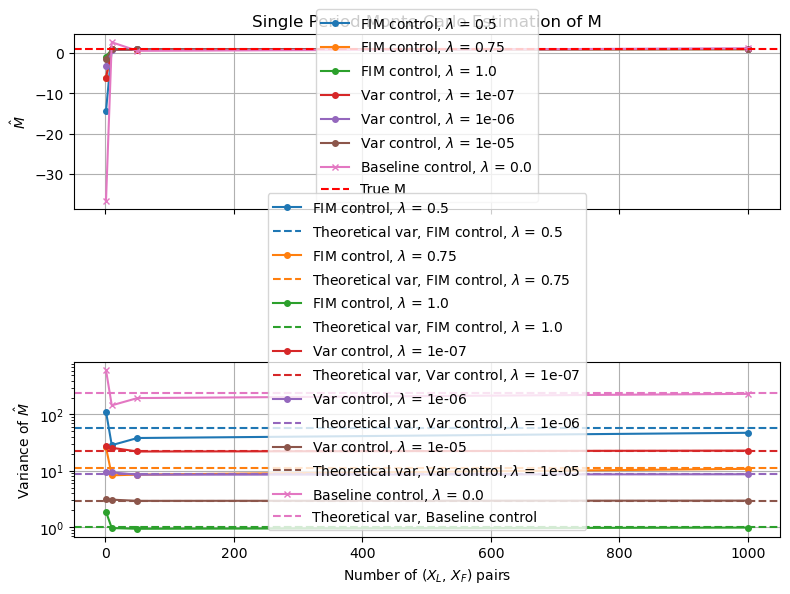

In [8]:
# single period monte carlo estimation of parameter M
def F(x):
    return 0.2 * torch.sin(2*np.pi * x / params.T)
    # return 0*torch.ones_like(x, device=params.device)

N = 50
T = 0.5

params = SystemParams()
params.A_L, params.A_F = -1.0, -1.0
params.B_L, params.B_F = 1.0, 1.0
params.sig_L, params.sig_F = 0.1, 0.1
params.M_true = 1.0
params.lamb_F = 1.
# params.lamb_L = 1.0
params.Q_L_T = 0.0
params.Q_L, params.Q_F = 0.0, 1.0
params.R_L, params.R_F = 1.0, 1.0
params.X_L_0, params.X_F_0 = 0.1, 0.1
params.T, params.N = T, N
params.device = device
params.time_grid = torch.linspace(0, params.T, params.N + 1, device=params.device)
params.dt = params.T / params.N


# num_single_periods = [1, 10, 50, 100, 250, 500, 750, 1000]
num_single_periods = [1, 10, 50, 1000]
analy_lamb_L_vals = [0.5,0.75, 1.0]
estM = {}
varM = {}
theoretical_var = {}

for val in analy_lamb_L_vals:
    params.lamb_L = val
    leader_analytic = LeaderLBSolver(params, F)
    running_estM = [0.0]
    running_var = [0.0]
    for size in num_single_periods:
        X_L, U_L = leader_analytic.simulate(batch=size, seed=size)
        X_F, U_F = torch.zeros(X_L.shape, device=params.device), torch.zeros(U_L.shape, device=params.device)
        for i in range(size):
            X_F[i:i+1, :], U_F[i:i+1, :] = simulate_follower(X_L[i:i+1, :], params, batch=1, seed=(2*i+1)*size)
        a_grid = compute_a_grid(params)
        f_grid = compute_f_grid(params)
        g = compute_b_grid(params, a_grid, X_L) / params.M_true
        num_first = torch.einsum('i,ji,ji->j', f_grid[1:], g, X_F)* params.dt
        num_second = torch.sum(g[:,:-1] * (X_F[:, 1:] - X_F[:, :-1]), dim=1)
        denom = int_trapz((params.B_F**4/params.R_F**2) * (g**2), params.dt)
        curr_M = (num_first - num_second) / denom
        new_M_est = curr_M.mean()
        new_var_est = (params.sig_F**2/denom).mean()
        # new_var_est = curr_M.var()
        if torch.isnan(new_M_est):
            new_M_est = running_estM[-1]
        if torch.isnan(new_var_est):
            new_var_est = running_var[-1]
        running_estM.append(new_M_est)
        running_var.append(new_var_est)
    estM[f"FIM control, $\lambda$ = {val}"] = running_estM[1:]  # skip the initial 0
    varM[f"FIM control, $\lambda$ = {val}"] = running_var[1:]  # skip the initial 0
    X_L, U_L = leader_analytic.simulate(batch=10000, seed=10000)
    theoretical_var[f"FIM control, $\lambda$ = {val}"] = estimate_var(X_L, params)
    # plt.plot(running_estM[1:])
    # plt.plot(running_var[1:])
    
baseline_params = params
baseline_params.lamb_L = 0.0
baseline_analytic = LeaderLBSolver(baseline_params, F)
running_estM = [0.0]
running_var = [0.0]
baseline_estM = None
baseline_varM = None
baseline_theoretical_var = None
for size in num_single_periods:
    X_L, U_L = baseline_analytic.simulate(batch=size, seed=size)
    X_F, U_F = torch.zeros(X_L.shape, device=params.device), torch.zeros(U_L.shape, device=params.device)
    for i in range(size):
        X_F[i:i+1, :], U_F[i:i+1, :] = simulate_follower(X_L[i:i+1, :], baseline_params, batch=1, seed=(2*i+1)*size)
    a_grid = compute_a_grid(baseline_params)
    f_grid = compute_f_grid(baseline_params)
    g = compute_b_grid(baseline_params, a_grid, X_L) / baseline_params.M_true
    num_first = torch.einsum('i,ji,ji->j', f_grid[1:], g, X_F)* baseline_params.dt
    num_second = torch.sum(g[:,:-1] * (X_F[:, 1:] - X_F[:, :-1]), dim=1)
    denom = int_trapz((baseline_params.B_F**4/baseline_params.R_F**2) * (g**2), baseline_params.dt)
    curr_M = (num_first - num_second) / denom
    new_M_est = curr_M.mean()
    new_var_est = (baseline_params.sig_F**2/denom).mean()
    # new_var_est = curr_M.var()
    if torch.isnan(new_M_est):
        new_M_est = running_estM[-1]
    if torch.isnan(new_var_est):
        new_var_est = running_var[-1]
    running_estM.append(new_M_est)
    running_var.append(new_var_est)
baseline_estM = running_estM[1:]  # skip the initial 0
baseline_varM = running_var[1:]  # skip the initial 0
X_L, U_L = baseline_analytic.simulate(batch=10000, seed=10000)
baseline_theoretical_var = estimate_var(X_L, baseline_params)

net_weight_files = [
    (1e-7, "/runs/promoting_madame/loss_3.532e-02_upd_6264.pt"),
    (1e-6, "/runs/how'd_fury/loss_1.416e-01_upd_7945.pt"),
    (1e-5, "/runs/arbitrary_aisle/loss_5.186e-01_upd_9910.pt"),
]

for lam_exact_val, weight_file in net_weight_files:
    net = DeepLSTMController()
    net.load_state_dict(torch.load(os.getcwd() + weight_file, map_location=device))
    net.to(device)
    u_NN = make_nn_policy(net, params)
    running_estM = [0.0]
    running_var = [0.0]
    for size in num_single_periods:
        X_L, U_L = simulate_leader(u_NN, params, batch=size, seed=size)
        X_L, U_L = X_L.detach(), U_L.detach()
        X_F, U_F = torch.zeros(X_L.shape, device=params.device), torch.zeros(U_L.shape, device=params.device)
        for i in range(size):
            X_F[i:i+1, :], U_F[i:i+1, :] = simulate_follower(X_L[i:i+1, :], params, batch=1, seed=(2*i+1)*size)
        a_grid = compute_a_grid(params)
        f_grid = compute_f_grid(params)
        g = compute_b_grid(params, a_grid, X_L) / params.M_true
        num_first = torch.einsum('i,ji,ji->j', f_grid[1:], g, X_F)* params.dt
        num_second = torch.sum(g[:,:-1] * (X_F[:, 1:] - X_F[:, :-1]), dim=1)
        denom = int_trapz((params.B_F**4/params.R_F**2) * (g**2), params.dt)
        curr_M = (num_first - num_second) / denom
        new_M_est = curr_M.mean()
        new_var_est = (params.sig_F**2 /denom).mean()
        # new_var_est = curr_M.var()
        if torch.isnan(new_M_est):
            new_M_est = running_estM[-1]
        if torch.isnan(new_var_est):
            new_var_est = running_var[-1]
        running_estM.append(new_M_est)
        running_var.append(new_var_est)
    estM[f"Var control, $\lambda$ = {lam_exact_val}"] = running_estM[1:]  # skip the initial 0
    varM[f"Var control, $\lambda$ = {lam_exact_val}"] = running_var[1:]  # skip the initial

    X_L, U_L = simulate_leader(u_NN, params, batch=10000, seed=10000)
    theoretical_var[f"Var control, $\lambda$ = {lam_exact_val}"] = estimate_var(X_L, params)
    # plt.plot(running_estM[1:])
    # plt.plot(running_var[1:])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for i, (lam_exact_val, running_estM) in enumerate(estM.items()):
    ax1.plot(num_single_periods, running_estM, label=f"{lam_exact_val}", marker='o', markersize=4, color=f'C{i}')

for i, (lam_exact_val, running_var) in enumerate(varM.items()):
    ax2.plot(num_single_periods, running_var, label=f"{lam_exact_val}", marker='o', markersize=4, color=f'C{i}')
    # horizontal line for theoretical variance
    ax2.axhline(theoretical_var[lam_exact_val], linestyle='--', label=f"Theoretical var, {lam_exact_val}", color=f'C{i}')

ax1.plot(num_single_periods, baseline_estM, label="Baseline control, $\lambda$ = 0.0", marker='x', markersize=4, color=f'C{len(estM)}')
ax2.plot(num_single_periods, baseline_varM, label="Baseline control, $\lambda$ = 0.0", marker='x', markersize=4, color=f'C{len(estM)}')
ax2.axhline(baseline_theoretical_var, linestyle='--', label="Theoretical var, Baseline control", color=f'C{len(estM)}')

ax1.set_ylabel('$\hat{M}$')
ax2.set_ylabel('Variance of $\hat{M}$')
ax2.set_yscale('log')
ax1.axhline(params.M_true, color='red', linestyle='--', label='True M')
ax1.set_title('Single Period Monte Carlo Estimation of M')
ax1.legend()
ax2.set_xlabel('Number of ($X_L$, $X_F$) pairs')
ax2.legend()
ax2.grid(True)
ax1.grid(True)
plt.tight_layout()
plt.show()

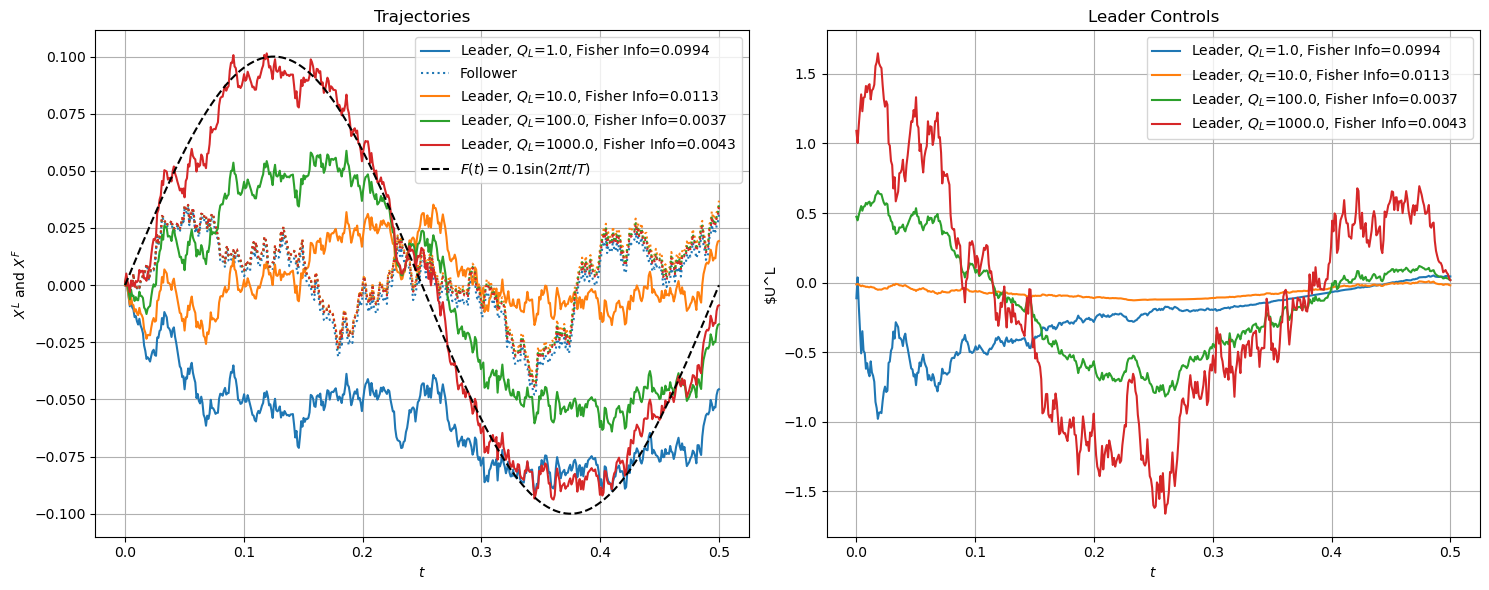

In [28]:
# show tradeoff between primary and info tasks
def F(x):
    return 0.1 * torch.sin(2*np.pi * x / params.T)

N = 500
T = 0.5

params = SystemParams()
params.A_L, params.A_F = -1.0, -1.0
params.B_L, params.B_F = 1.0, 1.0
params.sig_L, params.sig_F = 0.1, 0.1
params.M_true = 1.0
params.lamb_F = 1.0
params.lamb_L = 1.0
params.Q_L_T = 1.0
params.Q_L, params.Q_F = None, 1.0
params.R_L, params.R_F = 1.0, .85
params.X_L_0, params.X_F_0 = 0.0, 0.0
params.T, params.N = T, N
params.device = device
params.time_grid = torch.linspace(0, params.T, params.N + 1, device=params.device)
params.dt = params.T / params.N

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for i,Q_L in enumerate([1.,10.,100.,1000.]):
    params.Q_L = Q_L
    leader_analytic = LeaderLBSolver(params, F)
    X_L, U_L = leader_analytic.simulate(batch=1, seed=2)
    X_F, U_F = simulate_follower(X_L, params, batch=1, seed=3)
    Fisher_info = estimate_I_batch(leader_analytic.simulate(batch=10000, seed=2)[0], params=params)
    # round fisher info to 2 decimal places
    Fisher_info = round(Fisher_info, 4)
    ax1.plot(torch.linspace(0, params.T, X_L.shape[1]), X_L[0, :].cpu().numpy(), label=f'Leader, $Q_L$={Q_L}, Fisher Info={Fisher_info}', color=f'C{i}')
    if i == 0:
        ax1.plot(torch.linspace(0, params.T, X_F.shape[1]), X_F[0, :].cpu().numpy(), label='Follower', color=f'C{i}', linestyle=':')
    else:
        ax1.plot(torch.linspace(0,params.T, X_F.shape[1]), X_F[0, :].cpu().numpy(), color=f'C{i}', linestyle=':')
    ax2.plot(torch.linspace(0, params.T, U_L.shape[1]), U_L[0, :].cpu().numpy(), label=f'Leader, $Q_L$={Q_L}, Fisher Info={Fisher_info}', color=f'C{i}')

ax1.plot(torch.linspace(0, params.T, X_L.shape[1]), F(torch.linspace(0, params.T, X_L.shape[1])).cpu().numpy(), 'k--', label='$F(t)=0.1\sin(2\pi t / T)$')
ax1.set_xlabel('$t$')
ax1.set_ylabel('$X^L$ and $X^F$')
ax1.set_title('Trajectories')
ax1.legend()
ax1.grid()

ax2.set_xlabel('$t$')
ax2.set_ylabel('$U^L')
ax2.set_title('Leader Controls')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

/var/folders/bs/pjtn_x6x0vlg303wglbxqthm0000gn/T/ipykernel_69726/4074752735.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  exact_net.load_state_dict(torch.load(os.getc

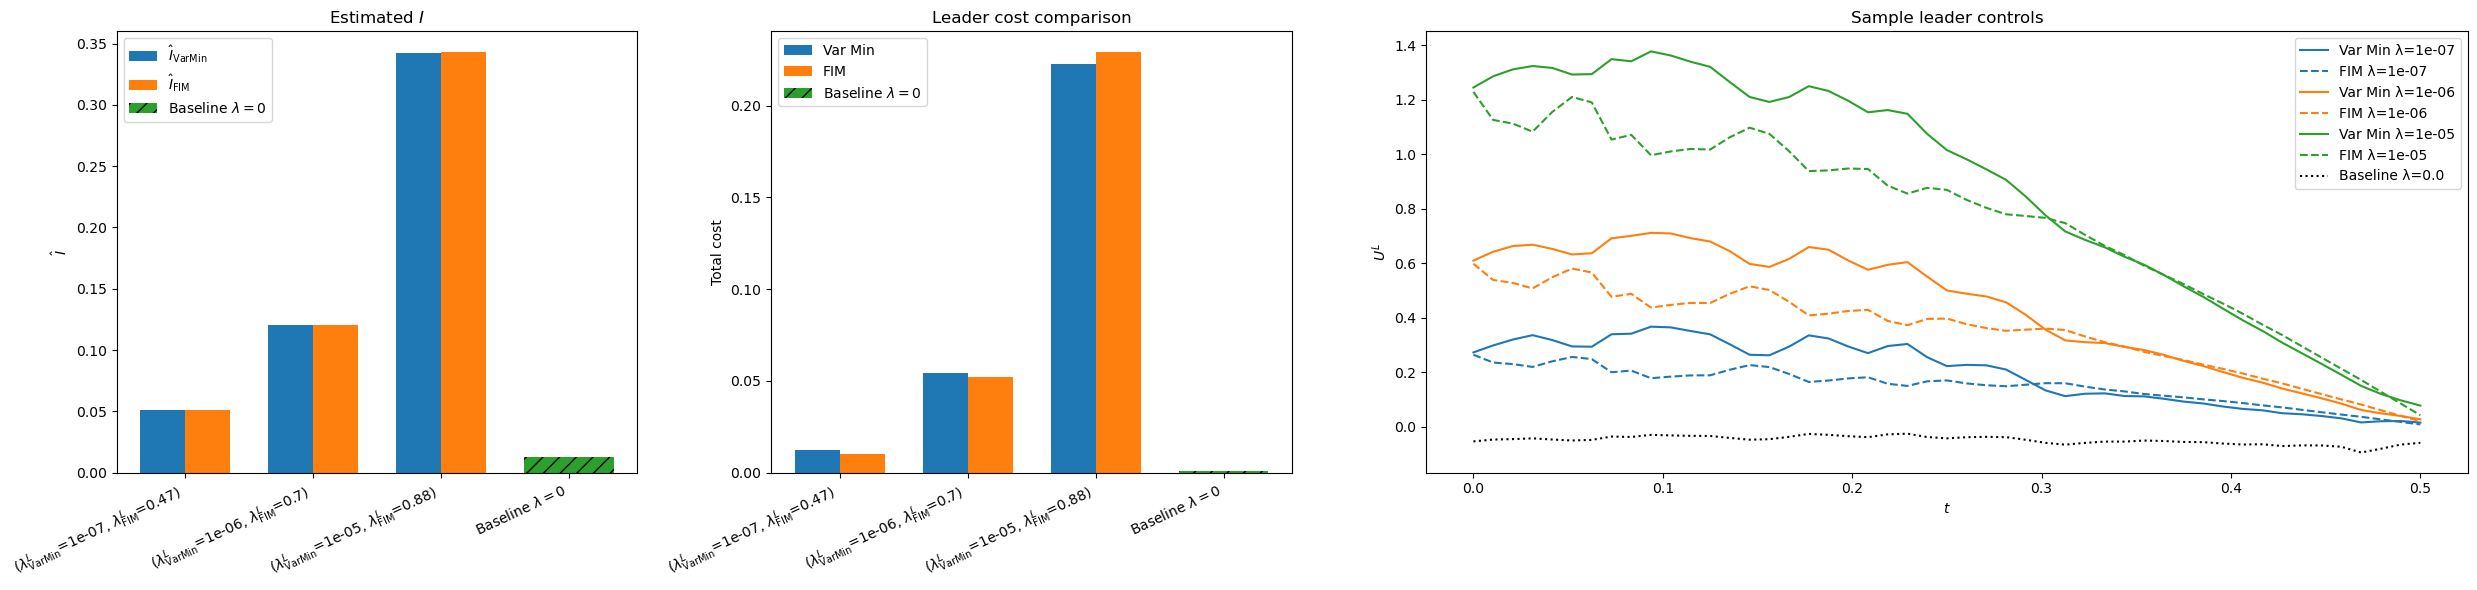

In [49]:

def F(x):
    # return torch.sin(2*np.pi * x / T)
    return 0 * torch.ones_like(x)

T, N = 0.5, 50

# note, R_F = 1.0, Q_F = 2.0, Q_L = 0.0, R_L = 1.
lamb_pairs = [
    (1e-7, .47),
    (1e-6, .698),
    (1e-5, .876),
]
net_weight_files = [
    (1e-7, "/runs/promoting_madame/loss_3.532e-02_upd_6264.pt"),
    (1e-6, "/runs/how'd_fury/loss_1.416e-01_upd_7945.pt"),
    (1e-5, "/runs/arbitrary_aisle/loss_5.186e-01_upd_9910.pt"),
]

combined_pairs = [(weight_file, lamb_L_exact, lamb_L_LB) for (lamb_L_exact, lamb_L_LB), (_, weight_file) in zip(lamb_pairs, net_weight_files)]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lambda_exact_vals               = []   # for x‑tick labels
lambda_lb_vals                  = []   # for x‑tick labels
estI_exact_vals, estI_lb_vals   = [], []
exact_cost_vals, lb_cost_vals   = [], []

fig, axs = plt.subplots(1, 3, figsize=(25, 6),
                        gridspec_kw={'width_ratios': [1, 1, 2]})
ax_estI, ax_cost, ax_ctrl = axs

for i, (weight_file, lamb_L_exact, lamb_L_LB) in enumerate(combined_pairs):

    params_exact = SystemParams()
    params_exact.A_L, params_exact.A_F = -1.0, -1.0
    params_exact.B_L, params_exact.B_F = 1.0, 1.0
    params_exact.sig_L, params_exact.sig_F = 0.1, 0.1
    params_exact.M_true, params_exact.lamb_F = 1.0, 1.0
    params_exact.lamb_L = lamb_L_exact
    params_exact.Q_L_T, params_exact.Q_L, params_exact.Q_F = 0.0, 0.0, 1.0
    params_exact.R_L, params_exact.R_F = 1.0, 1.0
    params_exact.X_L_0, params_exact.X_F_0 = 0.1, 0.1
    params_exact.T, params_exact.N = T, N
    params_exact.device = device
    params_exact.time_grid = torch.linspace(0, T, N + 1, device=device)
    params_exact.dt = T / N

    exact_net = DeepLSTMController()
    exact_net.load_state_dict(torch.load(os.getcwd() + weight_file,
                                         map_location=device))
    exact_net.to(device)

    X_L_exact, U_L_exact = simulate_leader(
        make_nn_policy(exact_net, params_exact),
        params_exact, batch=10000, seed=0
    )
    est_I = estimate_I_batch(X_L_exact, params_exact)

    # lamb_L_LB = (lamb_L_exact / (est_I ** 2))

    params_LB = SystemParams()
    # copy everything, then overwrite lamb_L
    for attr in vars(params_exact):
        setattr(params_LB, attr, getattr(params_exact, attr))
    params_LB.lamb_L = lamb_L_LB

    leader_lb = LeaderLBSolver(params_LB, F)
    X_L_lb, U_L_lb = leader_lb.simulate(batch=10000, seed=0)
    est_I_lb = estimate_I_batch(X_L_lb, params_LB)

    # exact_cost = exact_leader_total_cost(X_L_exact, U_L_exact, params_exact, F)
    # params_LB.lamb_L = lamb_L_exact
    # lb_cost = exact_leader_total_cost(X_L_lb, U_L_lb, params_exact, F)
    exact_cost = (1/2)*int_trapz(U_L_exact**2, params_exact.dt).mean()
    lb_cost = (1/2)*int_trapz(U_L_lb**2, params_LB.dt).mean()

    lambda_exact_vals.append(float(lamb_L_exact))
    lambda_lb_vals.append(float(lamb_L_LB))
    estI_exact_vals.append(float(est_I))
    estI_lb_vals.append(float(est_I_lb))
    exact_cost_vals .append(float(exact_cost))
    lb_cost_vals.append(float(lb_cost))

    ax_ctrl.plot(torch.linspace(0, params_exact.T, U_L_exact[0].shape[0]),
                 U_L_exact[0].detach().cpu().numpy(),
                 label=f'Var Min λ={lamb_L_exact}',
                 color=f'C{i}', linestyle='-')
    ax_ctrl.plot(torch.linspace(0, params_LB.T, U_L_lb[0].shape[0]),
                 U_L_lb[0].detach().cpu().numpy(),
                 label=f'FIM λ={lamb_L_exact}',
                 color=f'C{i}', linestyle='--')

# create a baseline control
params_baseline = SystemParams()
params_baseline.A_L, params_baseline.A_F = -1.0, -1.0
params_baseline.B_L, params_baseline.B_F = 1.0, 1.0
params_baseline.sig_L, params_baseline.sig_F = 0.1, 0.1
params_baseline.M_true, params_baseline.lamb_F = 1.0, 1.0
params_baseline.lamb_L = 0.0
params_baseline.Q_L_T, params_baseline.Q_L, params_baseline.Q_F = 1.0, 1.0, 1.0
params_baseline.R_L, params_baseline.R_F = 1.0, 1.0
params_baseline.X_L_0, params_baseline.X_F_0 = 0.1, 0.1
params_baseline.T, params_baseline.N = T, N
params_baseline.device = device
params_baseline.time_grid = torch.linspace(0, T, N + 1, device=device)
params_baseline.dt = T / N

baseline = LeaderLBSolver(params_baseline, F)
X_L_baseline, U_L_baseline = baseline.simulate(batch=10000, seed=0)
ax_ctrl.plot(torch.linspace(0, params_baseline.T, U_L_baseline[0].shape[0]),
             U_L_baseline[0].detach().cpu().numpy(),
             label='Baseline λ=0.0',
             color='k', linestyle=':')
estI_baseline = estimate_I_batch(X_L_baseline, params_baseline)
baseline_cost = (1/2)*int_trapz(U_L_baseline**2, params_baseline.dt).mean()



# x = np.arange(len(lambda_exact_vals)+1)
# width = 0.35


# ------------------------------------------------------------------
#  A.  append baseline statistics to the existing lists
# ------------------------------------------------------------------
lambda_exact_vals.append(0.0)           # add a dummy for xtick bookkeeping
lambda_lb_vals   .append(0.0)

estI_exact_vals .append(estI_baseline)  # we’ll plot these in BLUE    (Var‑Min)
estI_lb_vals    .append(estI_baseline)  # we’ll plot these in ORANGE  (FIM)
exact_cost_vals.append(baseline_cost)    # BLUE bar in cost panel
lb_cost_vals   .append(baseline_cost)    # ORANGE bar in cost panel

# ------------------------------------------------------------------
#  B.  build x‑coordinates
# ------------------------------------------------------------------
x        = np.arange(len(lambda_exact_vals))   # now = original 3 + baseline 1
width    = 0.35
big_width = 2 * width                          # baseline bar is twice as wide
base_idx  = len(lambda_exact_vals) - 1         # last slot

# ------------------------------------------------------------------
#  C.  Estimated‑I panel  (left)
# ------------------------------------------------------------------
ax_estI.bar(x - width/2, estI_exact_vals, width,
            color='tab:blue', label=r'$\hat I_{\mathrm{Var Min}}$')
ax_estI.bar(x + width/2, estI_lb_vals,    width,
            color='tab:orange', label=r'$\hat I_{\mathrm{FIM}}$')

# over‑plot the baseline bar twice as wide, centred on base_idx
ax_estI.bar(base_idx, estI_baseline, big_width,
            color='tab:green', hatch='//', label=r'Baseline $\lambda=0$')

ax_estI.set_ylabel(r'$\hat I$')
ax_estI.set_title(r'Estimated $I$')

# ------------------------------------------------------------------
#  D.  Cost panel  (middle)
# ------------------------------------------------------------------
ax_cost.bar(x - width/2, exact_cost_vals, width,  color='tab:blue',   label='Var Min')
ax_cost.bar(x + width/2, lb_cost_vals,    width,  color='tab:orange', label='FIM')

ax_cost.bar(base_idx, baseline_cost, big_width,
            color='tab:green', hatch='//', label=r'Baseline $\lambda=0$')

ax_cost.set_ylabel('Total cost')
ax_cost.set_title('Leader cost comparison')

# ------------------------------------------------------------------
#  E.  common x‑ticks / labels for both bar charts
# ------------------------------------------------------------------
pair_labels = [
    rf"($\lambda_{{\mathrm{{VarMin}}}}^L$={v:.2g}, "
    rf"$\lambda_{{\mathrm{{FIM}}}}^L$={u:.2g})"
    for v, u in zip(lambda_exact_vals[:-1], lambda_lb_vals[:-1])
]
pair_labels.append(r'Baseline $\lambda=0$')

for ax in (ax_estI, ax_cost):
    ax.set_xticks(x)
    ax.set_xticklabels(pair_labels, rotation=25, ha='right')

# deduplicate legends
for ax in (ax_estI, ax_cost):
    h, l = ax.get_legend_handles_labels()
    ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys())

# ------------------------------------------------------------------
#  F.  control panel (right) is already plotted above
# ------------------------------------------------------------------
ax_ctrl.set_xlabel('$t$')
ax_ctrl.set_ylabel('$U^L$')
ax_ctrl.set_title('Sample leader controls')
ax_ctrl.legend()

plt.tight_layout()
plt.show()



# ax_estI.bar(x - width/2, estI_exact_vals, width,
#             color='tab:blue',   label=r'$\hat I_{\mathrm{Var Min}}$')
# ax_estI.bar(x + width/2, estI_lb_vals,    width,
#             color='tab:orange', label=r'$\hat I_{\mathrm{FIM}}$')
# ax_estI.set_xticks(x)
# ax_estI.set_xticklabels([r"($\lambda_{\mathrm{Var Min}}^L$"+f"={v:.2f}, "+ r"$\lambda_{\mathrm{FIM}}^L$"+f"={u:.2f})" for v,u in zip(lambda_exact_vals, lambda_lb_vals)])
# ax_estI.set_ylabel(r'$\hat I$')
# ax_estI.set_title(r'Estimated $I$')
# ax_estI.legend()

# ax_cost.bar(x - width/2, exact_cost_vals, width, label='Var Min')
# ax_cost.bar(x + width/2, lb_cost_vals,    width, label='FIM')
# ax_cost.set_xticks(x)
# ax_cost.set_xticklabels([r"($\lambda_{\mathrm{Var Min}}^L$"+f"={v:.2f}, "+ r"$\lambda_{\mathrm{FIM}}^L$"+f"={u:.2f})" for v,u in zip(lambda_exact_vals, lambda_lb_vals)])
# ax_cost.set_ylabel('Total cost')
# ax_cost.set_title('Leader cost comparison')
# ax_cost.legend()

# ax_ctrl.set_xlabel('$t$')
# ax_ctrl.set_ylabel('$U^L$')
# ax_ctrl.set_title('Sample leader controls')
# ax_ctrl.legend()

# plt.tight_layout()
# plt.show()
